# **Proyecto: Predicción de Precio y Volatilidad de ETHUSDT**
## **Autores: Mariana Franco, Samuel Bermudez, Danier Conde**

## **Contexto del Problema**

**Ethereum (ETH)** es la **segunda criptomoneda por capitalización de mercado y uno de los activos más líquidos del ecosistema blockchain.** A diferencia de los mercados financieros tradicionales, opera 24/7 y **es susceptible a shocks exógenos abruptos** (noticias regulatorias, movimientos de ballenas, eventos on-chain), **lo que hace que su precio exhiba patrones de alta volatilidad y no linealidad.**

El **objetivo** de este proyecto es **construir un modelo de Deep Learning** — específicamente un **Perceptrón Multicapa (MLP)** — capaz de **predecir el precio de cierre de ETH/USDT con un horizonte de 7 días**, a partir de series de tiempo en frecuencia de 1 minuto descargadas directamente desde la **API pública de Binance**.

Este primer notebook cubre dos etapas fundamentales:
1. **Ingesta de datos**: descarga paginada de velas OHLCV desde la API de Binance.
2. **Análisis Exploratorio (EDA)**: caracterización estadística de la serie, construcción de features y verificación de propiedades que justifican el uso de un modelo de deep learning.

In [19]:
pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


In [20]:
import os
import time
import warnings
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import datetime, timezone
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss, acf
from scipy import stats

warnings.filterwarnings("ignore")

In [21]:
# Configuración global de plots
plt.rcParams.update({
    "figure.facecolor": "#0d1117",
    "axes.facecolor": "#161b22",
    "axes.edgecolor": "#30363d",
    "axes.labelcolor": "#e6edf3",
    "text.color": "#e6edf3",
    "xtick.color": "#8b949e",
    "ytick.color": "#8b949e",
    "grid.color": "#21262d",
    "grid.linestyle": "--",
    "grid.alpha": 0.5,
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "figure.dpi": 120,
})

COLORS = {
    "price": "#58a6ff",
    "returns": "#3fb950",
    "vol": "#f78166",
    "accent": "#d2a8ff",
    "warning": "#e3b341",
    "neutral": "#8b949e",
}

print("Librerías importadas correctamente")
print(f"Timestamp de ejecución: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")


Librerías importadas correctamente
Timestamp de ejecución: 2026-04-24 10:03:30


In [22]:
# --- CELDA 3: Configuración de parámetros de descarga ---
# Se define la ventana temporal para la descarga. 28 días de datos en frecuencia
# de 1 minuto corresponden a 28 * 24 * 60 = 40.320 filas. La API de Binance
# entrega un máximo de 1.000 registros por request, por lo que se necesita
# una función de paginación.

SYMBOL = "ETHUSDT"
INTERVAL = "1m"           # Frecuencia de 1 minuto
DAYS_BACK = 60            # Días hacia atrás desde hoy
BASE_URL = "https://api.binance.com/api/v3/klines"
LIMIT_PER_REQUEST = 1000  # Máximo permitido por Binance

print(f"   Configuración:")
print(f"   Símbolo: {SYMBOL}")
print(f"   Intervalo: {INTERVAL}")
print(f"   Días de datos: {DAYS_BACK}")
print(f"   Filas esperadas: ~{DAYS_BACK * 24 * 60:,}")

   Configuración:
   Símbolo: ETHUSDT
   Intervalo: 1m
   Días de datos: 60
   Filas esperadas: ~86,400


## **Ingesta de Datos desde la API de Binance**

Optamos por datos en frecuencia de **1 minuto** para capturar la microestructura del mercado: movimientos intradiarios, picos de volumen y reacciones rápidas a eventos. Con una ventana de 60 días, el dataset resultante ronda las **86,400 observaciones brutas**, aunque tras el procesamiento se retienen ~41,760 filas con features completas (la diferencia corresponde a los lags necesarios para calcular indicadores como la volatilidad realizada).

La fuente es el endpoint `/api/v3/klines` de Binance, que devuelve velas OHLCV (Open, High, Low, Close, Volume). Cada fila representa un intervalo de 1 minuto con su precio de apertura, máximo, mínimo, cierre y volumen transado.

In [23]:
import requests
import pandas as pd
import time
from datetime import datetime, timezone

# --- CONFIGURACIÓN GLOBAL (Faltaba en tu código) ---
BASE_URL = "https://api.binance.com/api/v3/klines"
LIMIT_PER_REQUEST = 1000  # Máximo permitido por Binance [cite: 72]
SYMBOL = "ETHUSDT"        # Índice de Ethereum solicitado
INTERVAL = "1m"           # Frecuencia de 1 minuto [cite: 93]
DAYS_BACK = 30            # Ajusta según la cantidad de datos que necesites

def fetch_binance_klines(symbol: str, interval: str, days_back: int) -> pd.DataFrame:
    """
    Descarga datos OHLCV de Binance con paginación automática.
    """
    # Configuración de tiempos en milisegundos
    now_ms = int(datetime.now(timezone.utc).timestamp() * 1000)
    start_ms = now_ms - (days_back * 24 * 60 * 60 * 1000)
    end_ms = now_ms

    all_klines = []
    current_start = start_ms
    request_count = 0

    print(f"Iniciando descarga de {symbol} ({interval}) — {days_back} días...")
    
    while current_start < end_ms:
        params = {
            "symbol": symbol,
            "interval": interval,
            "startTime": current_start,
            "endTime": end_ms,
            "limit": LIMIT_PER_REQUEST,
        }

        try:
            response = requests.get(BASE_URL, params=params, timeout=30)
            response.raise_for_status()
            batch = response.json()

            if not batch:
                break

            all_klines.extend(batch)
            # El primer elemento de cada vela es el Open Time [cite: 84]
            current_start = batch[-1][0] + 1  
            request_count += 1

            # Rate limit preventivo (Binance permite 1200 weight/min) [cite: 81]
            time.sleep(0.1)  

            if request_count % 10 == 0:
                print(f"Requests: {request_count} | Filas: {len(all_klines):,}")

        except requests.RequestException as e:
            print(f"Error: {e}. Reintentando en 5s...")
            time.sleep(5)
            continue

    # --- Procesamiento del DataFrame ---
    columns = [
        "open_time", "open", "high", "low", "close", "volume",
        "close_time", "quote_volume", "trades",
        "taker_buy_base", "taker_buy_quote", "ignore"
    ]
    df = pd.DataFrame(all_klines, columns=columns)

    # Conversión técnica de tipos [cite: 88, 89]
    numeric_cols = ["open", "high", "low", "close", "volume"]
    df[numeric_cols] = df[numeric_cols].astype(float)
    
    # Formateo de fechas y limpieza [cite: 87, 90]
    df["open_time"] = pd.to_datetime(df["open_time"], unit="ms", utc=True)
    df.set_index("open_time", inplace=True)
    df = df[["open", "high", "low", "close", "volume"]] # Solo las columnas necesarias
    
    print(f"\nDescarga completa: {len(df):,}")
    return df

# Ejecución
try:
    df_raw = fetch_binance_klines(SYMBOL, INTERVAL, DAYS_BACK)
    display(df_raw.head())
except Exception as e:
    print(f"Ocurrió un error general: {e}")


Iniciando descarga de ETHUSDT (1m) — 30 días...
Requests: 10 | Filas: 10,000
Requests: 20 | Filas: 20,000
Requests: 30 | Filas: 30,000
Requests: 40 | Filas: 40,000

Descarga completa: 43,200


,open,high,low,close,volume
open_time,,,,,
2026-03-25 15:04:00+00:00,2174.95,2175.32,2174.77,2174.95,76.1802
2026-03-25 15:05:00+00:00,2174.95,2175.76,2173.68,2173.68,135.5562
2026-03-25 15:06:00+00:00,2173.68,2173.68,2170.18,2170.32,529.5035
2026-03-25 15:07:00+00:00,2170.33,2170.78,2165.23,2166.97,692.9544
2026-03-25 15:08:00+00:00,2166.96,2168.14,2165.39,2166.95,570.3089


## **Feature Engineering**

Con el precio de cierre como base, construimos un conjunto de **variables derivadas** que buscan capturar diferentes dimensiones de la dinámica del mercado. La elección de estas features está directamente motivada por los resultados del EDA estadístico:

| Feature | Descripción | Motivación |
|---|---|---|
| `log_return` | Log-retorno minuto a minuto | Serie estacionaria; elimina tendencia del precio |
| `realized_vol_60` | Volatilidad realizada en ventana de 60 min | Captura volatilidad de corto plazo |
| `realized_vol_1440` | Volatilidad realizada en ventana de 1 día | Captura régimen de volatilidad diaria |
| `price_range` | High − Low por vela | Proxy de incertidumbre instantánea |
| `vwap` | Precio promedio ponderado por volumen | Referencia de precio "justo" del mercado |
| `volume_zscore` | Volumen estandarizado (media/std móvil) | Detecta picos de actividad inusuales |
| `momentum_60/240/1440` | Diferencia de precio respecto a t−n | Captura tendencia a distintas escalas |

Estas features son el input del MLP en el Notebook 2. La selección se hizo buscando representar precio, retornos, volatilidad y volumen de forma compacta, evitando redundancias excesivas que puedan perjudicar el entrenamiento.

In [24]:
# --- CELDA 5: Feature Engineering Financiero ---
# Se calculan las variables derivadas esenciales para el modelo:
# - log_return: retorno logarítmico instantáneo (estacionario, aditivo)
# - realized_vol: volatilidad realizada como std de retornos en ventana rodante
# - price_range: amplitud de la vela (proxy de volatilidad intraperiodo)
# - vwap: precio ponderado por volumen (referencia de valor justo)

def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """Construye features financieras a partir de datos OHLCV."""
    fe = df.copy()

    # Retorno logarítmico: log(P_t / P_{t-1})
    # Propiedades clave: ~ Normal, aditivo en tiempo, estacionario
    fe["log_return"] = np.log(fe["close"] / fe["close"].shift(1))

    # Volatilidad realizada (ventana de 60 minutos = 1 hora)
    fe["realized_vol_60"] = fe["log_return"].rolling(window=60).std() * np.sqrt(60)

    # Volatilidad realizada de largo plazo (ventana de 1440 min = 1 día)
    fe["realized_vol_1440"] = fe["log_return"].rolling(window=1440).std() * np.sqrt(1440)

    # Rango de precio (High - Low) normalizado por precio de apertura
    fe["price_range"] = (fe["high"] - fe["low"]) / fe["open"]

    # VWAP: Volume Weighted Average Price (ventana diaria)
    typical_price = (fe["high"] + fe["low"] + fe["close"]) / 3
    fe["vwap"] = (typical_price * fe["volume"]).rolling(1440).sum() / fe["volume"].rolling(1440).sum()

    # Volumen normalizado (z-score rodante)
    vol_mean = fe["volume"].rolling(1440).mean()
    vol_std = fe["volume"].rolling(1440).std()
    fe["volume_zscore"] = (fe["volume"] - vol_mean) / vol_std

    # Momentum de precio (cambio % en las últimas N velas)
    for lag in [60, 240, 1440]:
        fe[f"momentum_{lag}"] = fe["close"].pct_change(lag)

    # Eliminar NaN iniciales (producto del rolling)
    fe.dropna(inplace=True)

    return fe


df = engineer_features(df_raw)

print(f"Features construidas. Shape final: {df.shape}")
print(f"Columnas disponibles:")
for col in df.columns:
    print(f"   - {col}: {df[col].dtype}")

Features construidas. Shape final: (41760, 14)
Columnas disponibles:
   - open: float64
   - high: float64
   - low: float64
   - close: float64
   - volume: float64
   - log_return: float64
   - realized_vol_60: float64
   - realized_vol_1440: float64
   - price_range: float64
   - vwap: float64
   - volume_zscore: float64
   - momentum_60: float64
   - momentum_240: float64
   - momentum_1440: float64


In [25]:
# --- CELDA 6: Estadísticas Descriptivas ---

print("=" * 65)
print("ESTADÍSTICAS DESCRIPTIVAS - ETHUSDT")
print("=" * 65)

summary_cols = ["close", "log_return", "realized_vol_60", "volume"]
desc = df[summary_cols].describe().T
desc["skewness"] = df[summary_cols].skew()
desc["kurtosis"] = df[summary_cols].kurtosis()
print(desc.round(6).to_string())

print("\nInterpretación Estadística:")
print(f"  • Precio medio ETH    : ${df['close'].mean():,.2f}")
print(f"  • Retorno medio (1min): {df['log_return'].mean()*100:.6f}% (Cercano a cero, confirmando estacionariedad)")
print(f"  • Curtosis retornos   : {df['log_return'].kurtosis():.4f}")
print("    -> Al tener una curtosis mucho mayor a 3 (leptocúrtica), comprobamos que la distribución")
print("       tiene 'colas pesadas'. Esto indica que ETH presenta saltos de precio extremos con")
print("       mayor frecuencia que una distribución normal. Justamente por estas no-linealidades,")
print("       se justifica el uso de arquitecturas de Deep Learning para capturar la volatilidad.")

ESTADÍSTICAS DESCRIPTIVAS - ETHUSDT
                   count         mean         std          min          25%          50%          75%           max  skewness    kurtosis
close            41760.0  2197.687246  132.239657  1942.140000  2061.657500  2202.525000  2322.572500   2463.860000 -0.024360   -1.403580
log_return       41760.0     0.000003    0.000723    -0.010774    -0.000313     0.000000     0.000318      0.014245  0.581237   20.762700
realized_vol_60  41760.0     0.005015    0.002498     0.001063     0.003346     0.004455     0.006051      0.016464  1.517125    3.073655
volume           41760.0   211.769476  433.068319     0.500400    48.920450   100.381700   214.098950  16539.388400  9.841685  173.894812

Interpretación Estadística:
  • Precio medio ETH    : $2,197.69
  • Retorno medio (1min): 0.000260% (Cercano a cero, confirmando estacionariedad)
  • Curtosis retornos   : 20.7627
    -> Al tener una curtosis mucho mayor a 3 (leptocúrtica), comprobamos que la distribución


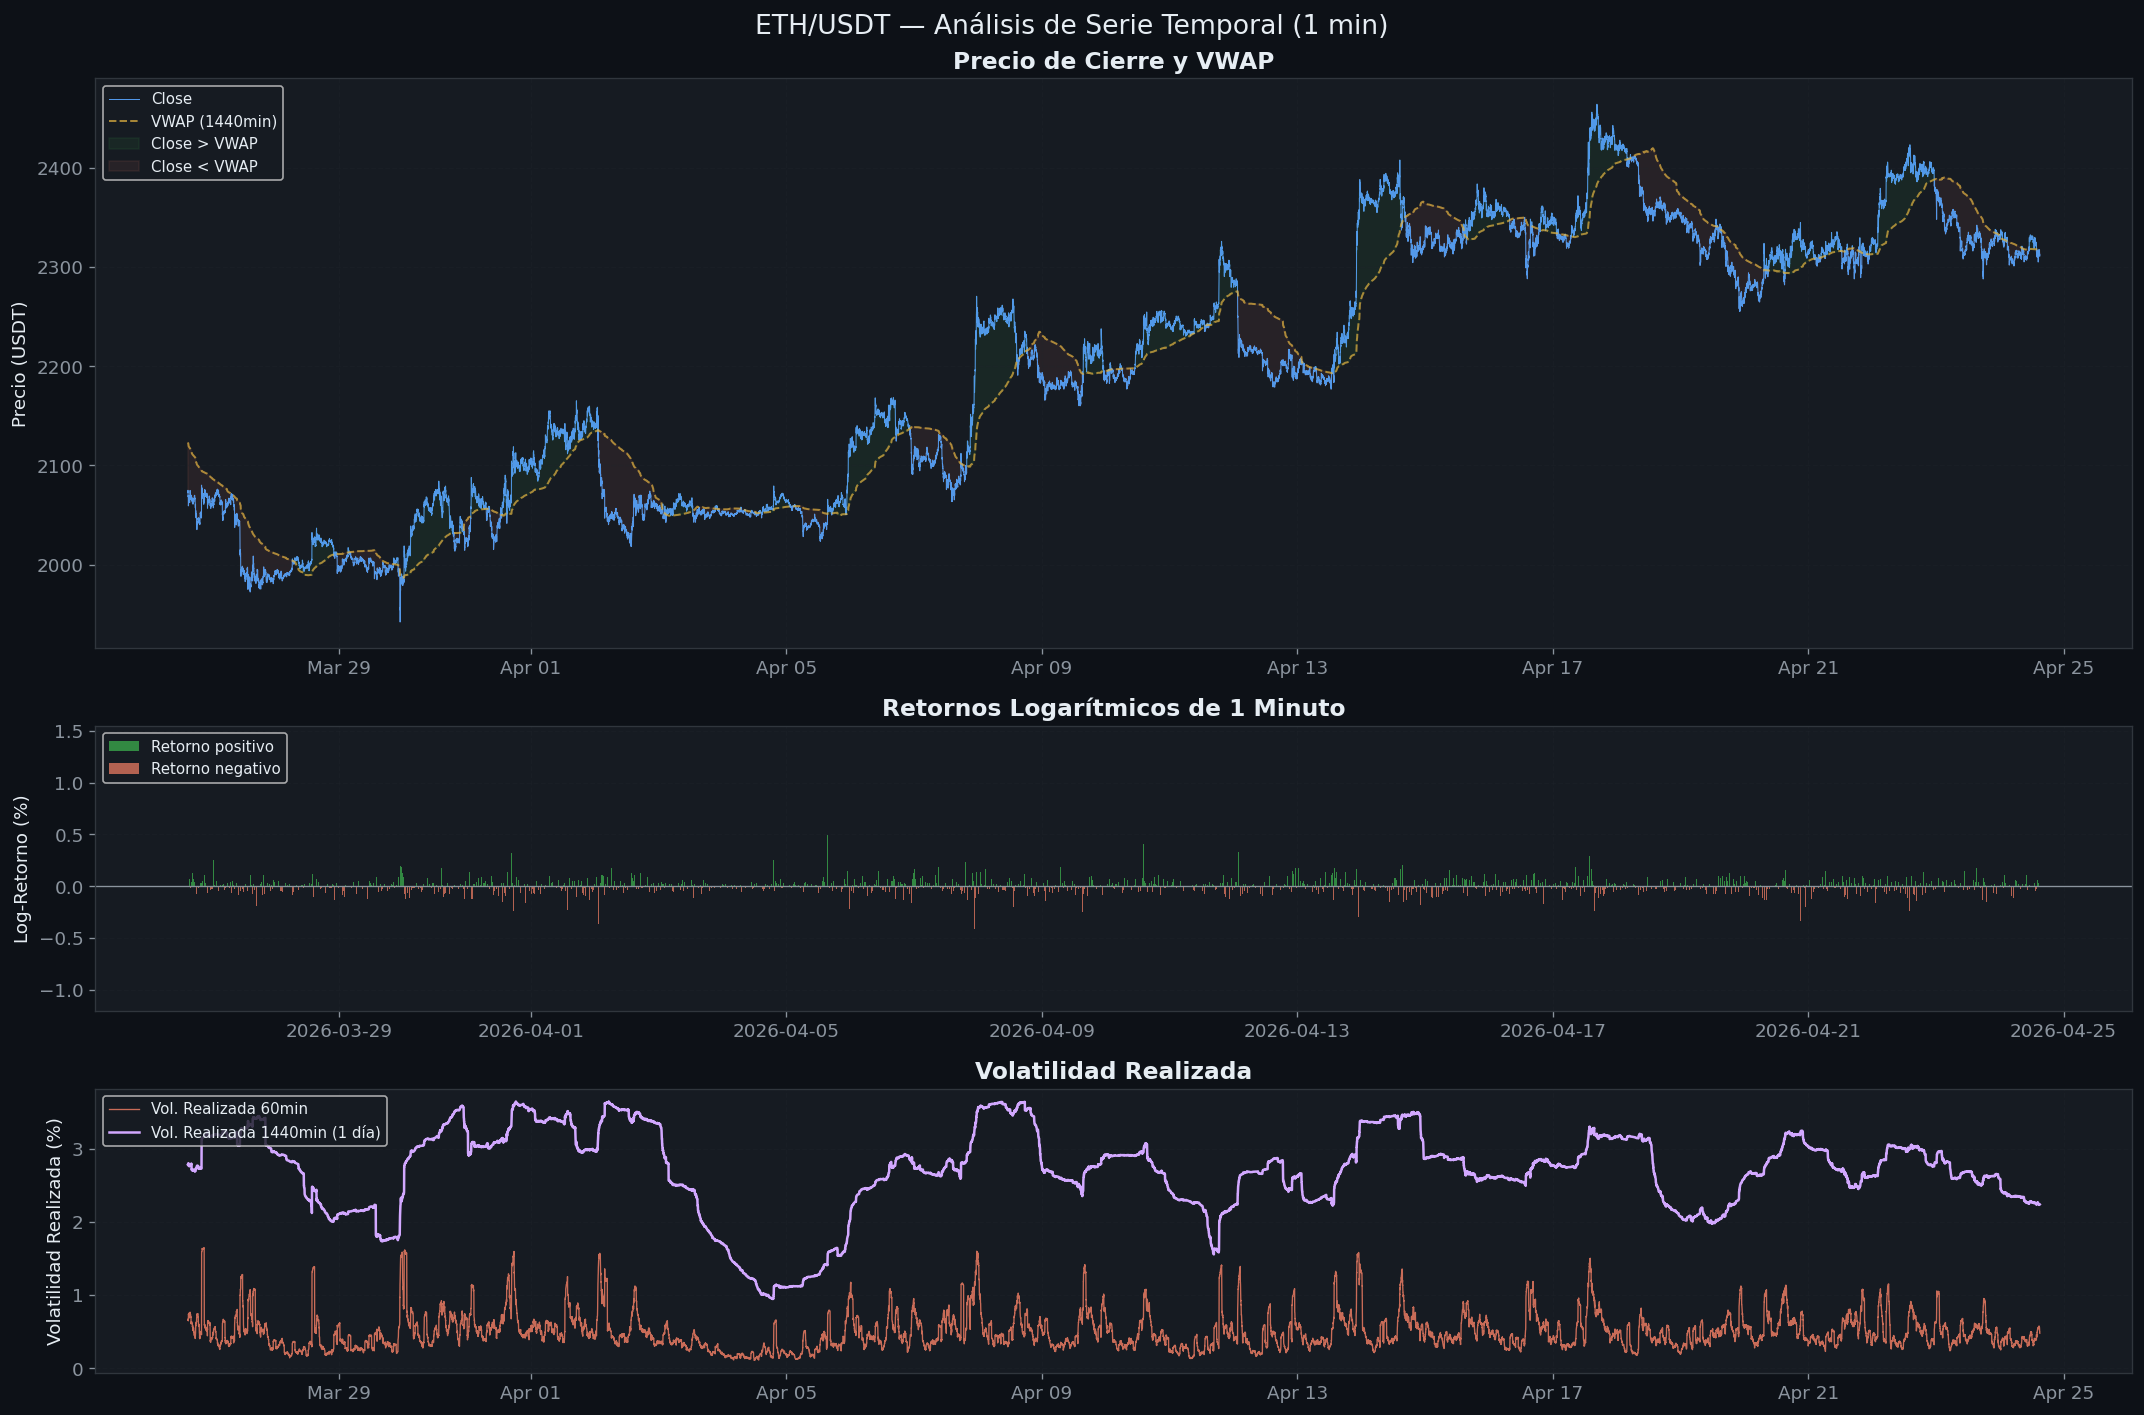

In [26]:
# --- CELDA 7: VISUALIZACIÓN 1 — Serie de Precio de Cierre ---
# Se grafica la serie temporal completa para identificar tendencias,
# rupturas estructurales y patrones de alta frecuencia.

fig, axes = plt.subplots(3, 1, figsize=(18, 12), gridspec_kw={"height_ratios": [3, 1.5, 1.5]})
fig.suptitle("ETH/USDT — Análisis de Serie Temporal (1 min)", fontsize=16, y=0.98)

# Panel 1: Precio de cierre con VWAP
ax1 = axes[0]
ax1.plot(df.index, df["close"], color=COLORS["price"], linewidth=0.6, alpha=0.9, label="Close")
ax1.plot(df.index, df["vwap"], color=COLORS["warning"], linewidth=1.2,
         alpha=0.7, linestyle="--", label="VWAP (1440min)")
ax1.fill_between(df.index, df["close"], df["vwap"],
                 where=(df["close"] >= df["vwap"]),
                 alpha=0.08, color=COLORS["returns"], label="Close > VWAP")
ax1.fill_between(df.index, df["close"], df["vwap"],
                 where=(df["close"] < df["vwap"]),
                 alpha=0.08, color=COLORS["vol"], label="Close < VWAP")
ax1.set_ylabel("Precio (USDT)")
ax1.legend(loc="upper left", fontsize=9)
ax1.set_title("Precio de Cierre y VWAP")
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax1.grid(True, alpha=0.3)

# Panel 2: Retornos logarítmicos
ax2 = axes[1]
returns = df["log_return"] * 100
pos_mask = returns >= 0
ax2.bar(df.index[pos_mask], returns[pos_mask], color=COLORS["returns"],
        width=0.0005, alpha=0.7, label="Retorno positivo")
ax2.bar(df.index[~pos_mask], returns[~pos_mask], color=COLORS["vol"],
        width=0.0005, alpha=0.7, label="Retorno negativo")
ax2.axhline(0, color=COLORS["neutral"], linewidth=0.8)
ax2.set_ylabel("Log-Retorno (%)")
ax2.legend(loc="upper left", fontsize=9)
ax2.set_title("Retornos Logarítmicos de 1 Minuto")
ax2.grid(True, alpha=0.3)

# Panel 3: Volatilidad realizada
ax3 = axes[2]
ax3.plot(df.index, df["realized_vol_60"] * 100, color=COLORS["vol"],
         linewidth=0.8, alpha=0.8, label="Vol. Realizada 60min")
ax3.plot(df.index, df["realized_vol_1440"] * 100, color=COLORS["accent"],
         linewidth=1.5, label="Vol. Realizada 1440min (1 día)")
ax3.set_ylabel("Volatilidad Realizada (%)")
ax3.legend(loc="upper left", fontsize=9)
ax3.set_title("Volatilidad Realizada")
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


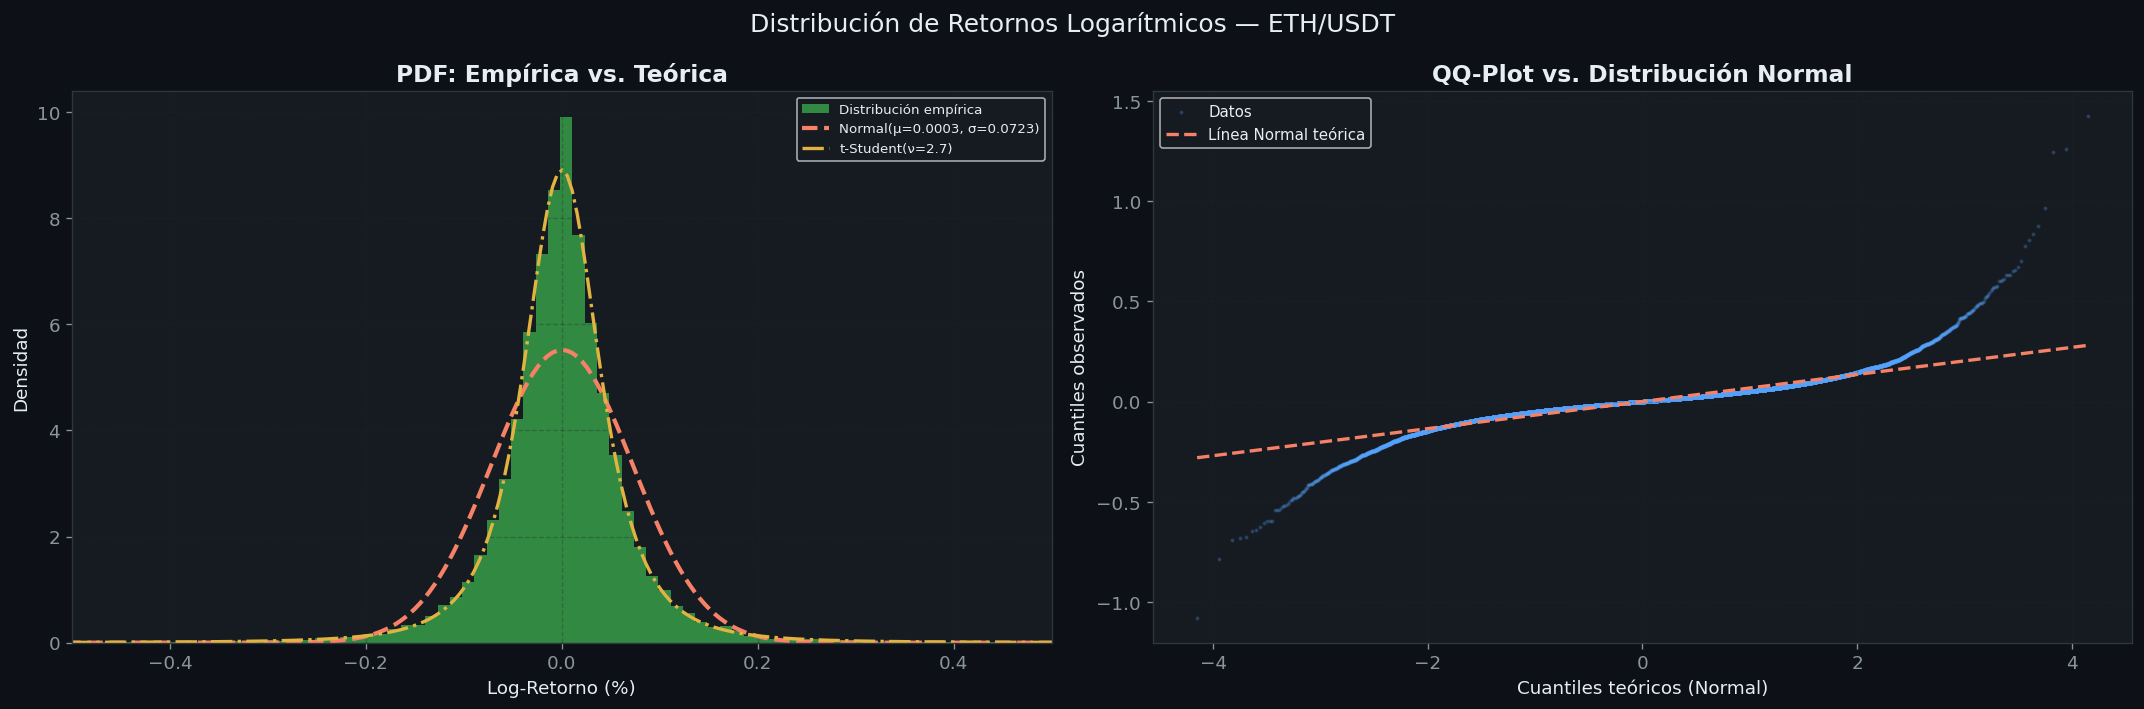

In [27]:
# --- CELDA 8: VISUALIZACIÓN 2 — Distribución de Retornos ---
# Se analiza la distribución empírica vs. la Normal teórica.


fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle("Distribución de Retornos Logarítmicos — ETH/USDT", fontsize=15)

returns_clean = df["log_return"].dropna() * 100

# Histograma vs Normal
ax1 = axes[0]
ax1.hist(returns_clean, bins=200, density=True, color=COLORS["returns"],
         alpha=0.7, label="Distribución empírica", edgecolor="none")
mu, sigma = returns_clean.mean(), returns_clean.std()
x = np.linspace(returns_clean.min(), returns_clean.max(), 500)
normal_pdf = stats.norm.pdf(x, mu, sigma)
ax1.plot(x, normal_pdf, color=COLORS["vol"], linewidth=2.5,
         label=f"Normal(μ={mu:.4f}, σ={sigma:.4f})", linestyle="--")
# Ajuste t de Student para cola pesada
df_t, loc_t, scale_t = stats.t.fit(returns_clean)
ax1.plot(x, stats.t.pdf(x, df_t, loc_t, scale_t),
         color=COLORS["warning"], linewidth=2, linestyle="-.",
         label=f"t-Student(ν={df_t:.1f})")
ax1.set_xlabel("Log-Retorno (%)")
ax1.set_ylabel("Densidad")
ax1.set_title("PDF: Empírica vs. Teórica")
ax1.legend(fontsize=8)
ax1.set_xlim(-0.5, 0.5)
ax1.grid(True, alpha=0.3)

# QQ-Plot
ax2 = axes[1]
(osm, osr), (slope, intercept, r) = stats.probplot(returns_clean, dist="norm")
ax2.scatter(osm, osr, color=COLORS["price"], alpha=0.2, s=2, label="Datos")
ax2.plot(osm, slope * np.array(osm) + intercept,
         color=COLORS["vol"], linewidth=2, linestyle="--", label="Línea Normal teórica")
ax2.set_xlabel("Cuantiles teóricos (Normal)")
ax2.set_ylabel("Cuantiles observados")
ax2.set_title("QQ-Plot vs. Distribución Normal")
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)




plt.tight_layout()
plt.show()


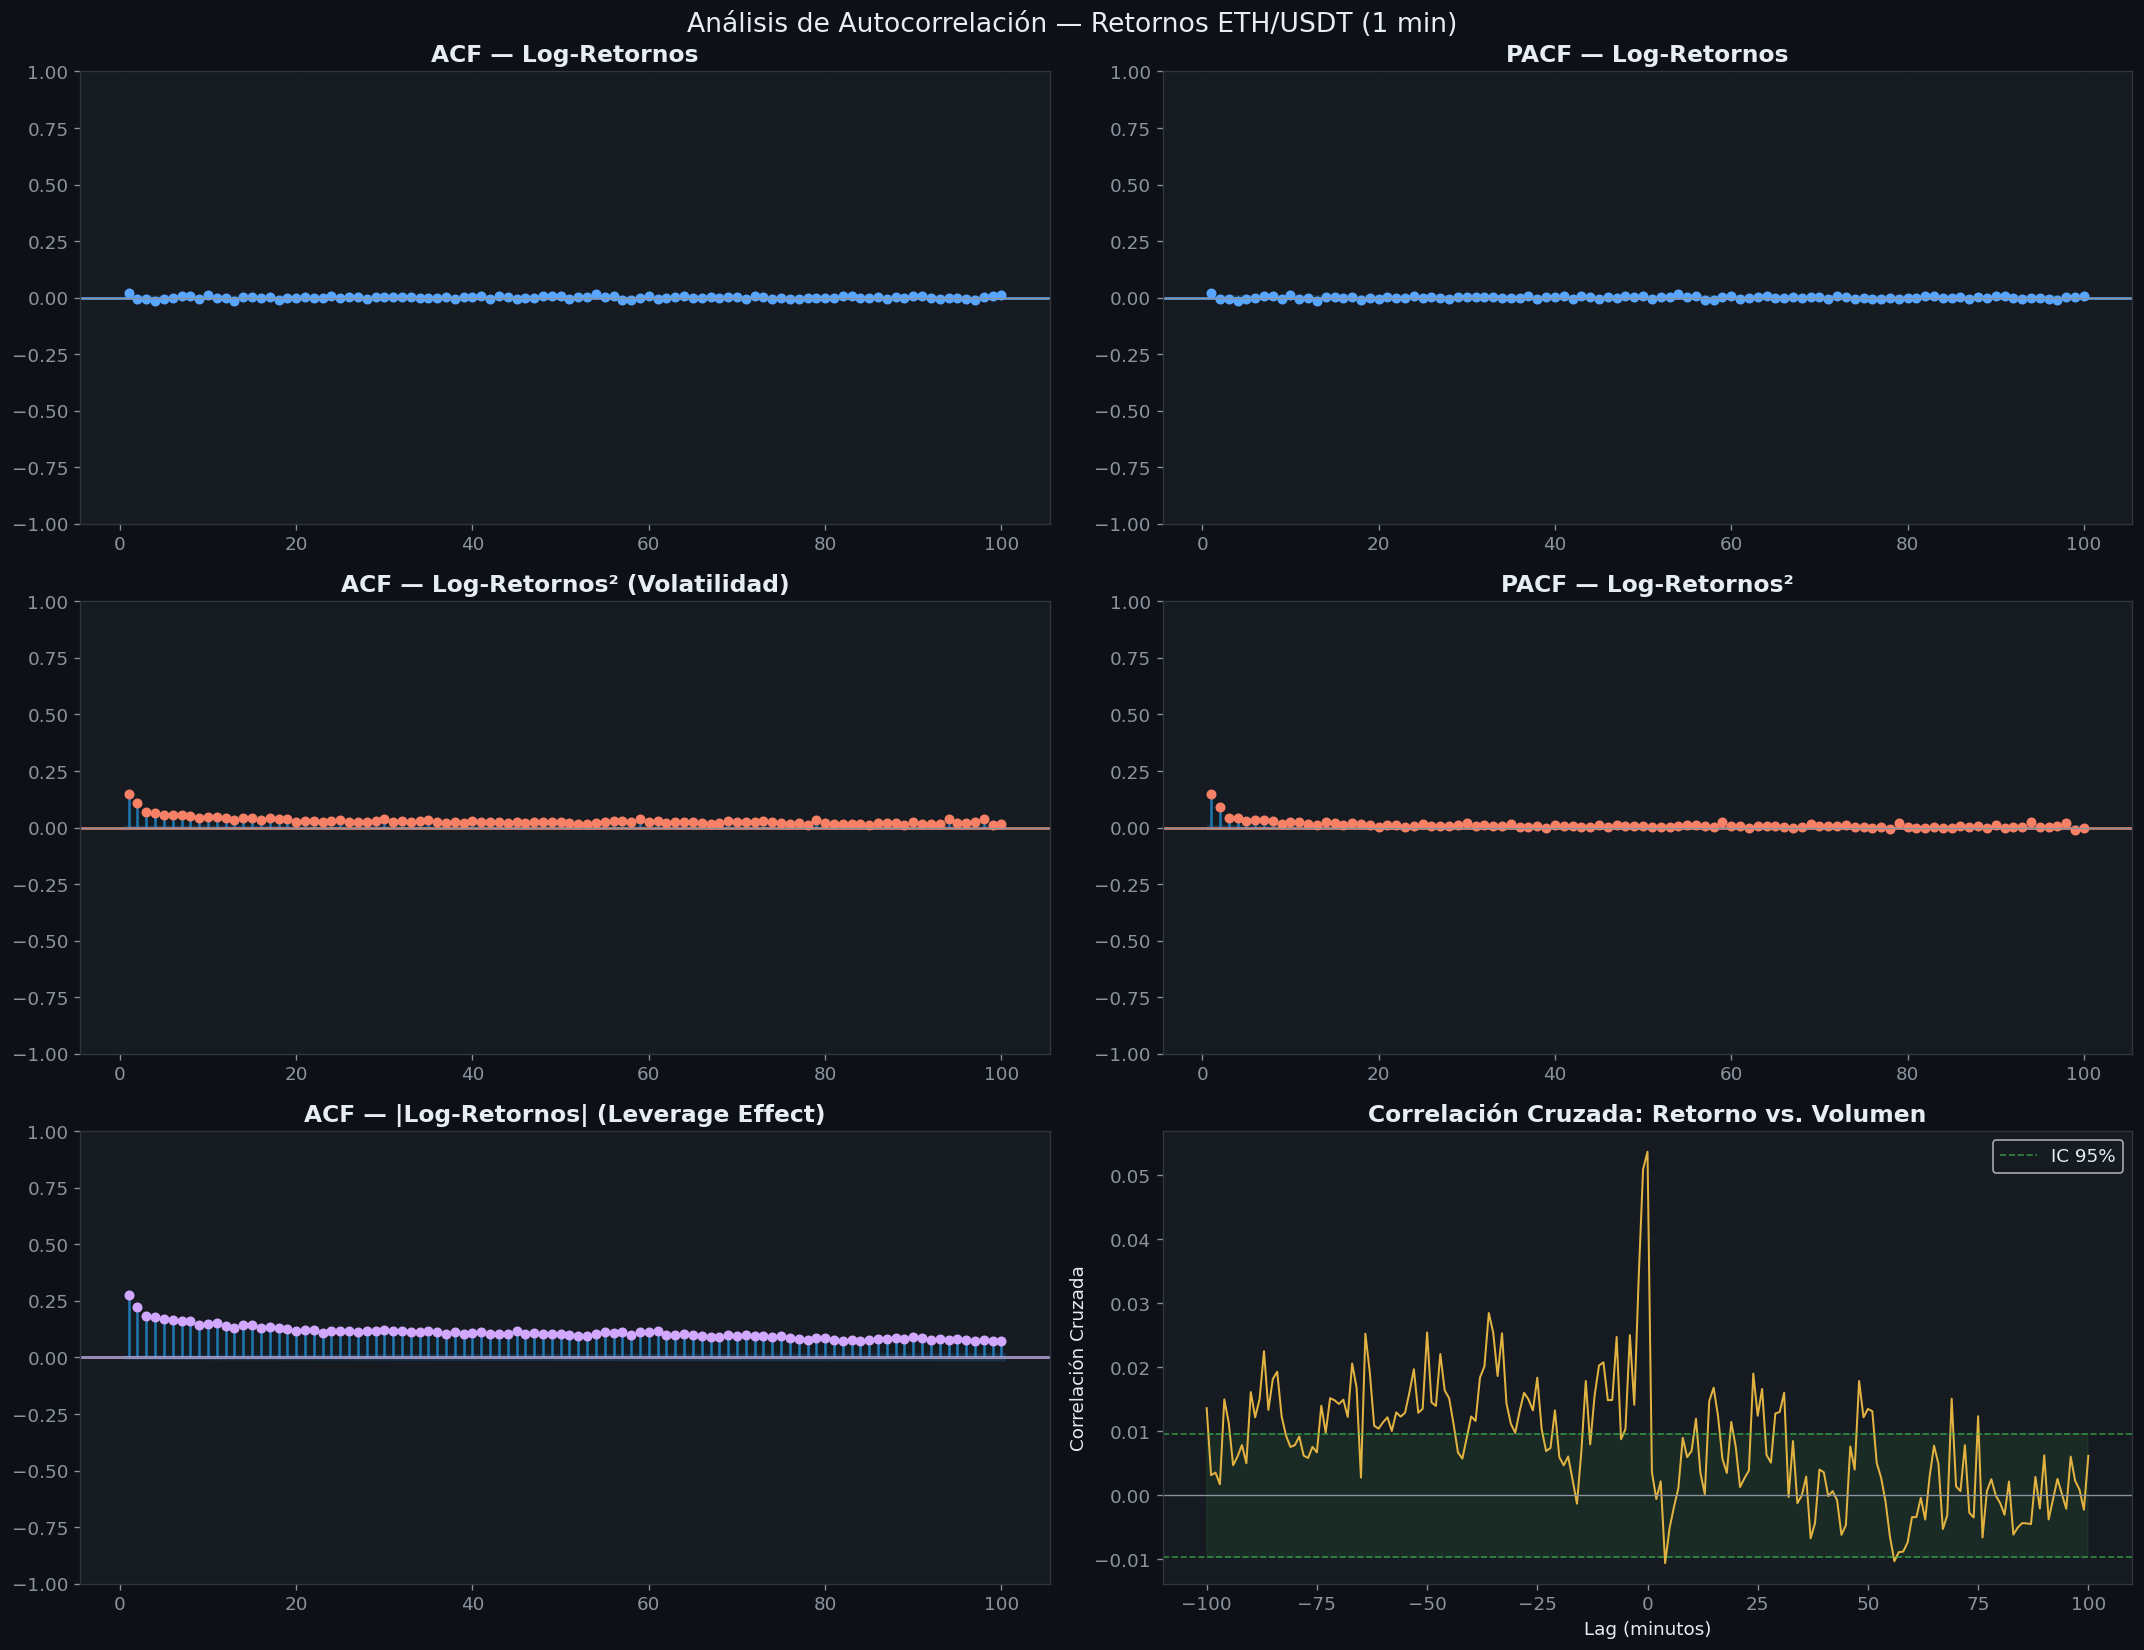

In [ ]:
# --- CELDA 9: VISUALIZACIÓN 3 — ACF/PACF de Retornos y Retornos al Cuadrado ---

# 1. ACF de retornos: Si hay autocorrelación → predictibilidad lineal
# 2. ACF de retornos² (volatilidad): Si hay autocorrelación → heterocedasticidad
#    condicional (efecto ARCH/GARCH) que los modelos lineales NO capturan bien
# 3. ACF de |retornos|: Confirma clustering de volatilidad (leverage effect)

fig, axes = plt.subplots(3, 2, figsize=(18, 14))
fig.suptitle("Análisis de Autocorrelación — Retornos ETH/USDT (1 min)", fontsize=16)

lags_to_plot = 100
returns_series = df["log_return"].dropna()
returns_sq = returns_series ** 2
returns_abs = returns_series.abs()

# Fila 1: Retornos logarítmicos
plot_acf(returns_series, lags=lags_to_plot, ax=axes[0, 0],
         color=COLORS["price"], title="ACF — Log-Retornos",
         alpha=0.05, zero=False)
axes[0, 0].axhline(0, color=COLORS["neutral"], linewidth=0.8)

plot_pacf(returns_series, lags=lags_to_plot, ax=axes[0, 1],
          color=COLORS["price"], title="PACF — Log-Retornos",
          alpha=0.05, zero=False, method="ywm")
axes[0, 1].axhline(0, color=COLORS["neutral"], linewidth=0.8)

# Fila 2: Retornos al cuadrado (proxy de volatilidad)
plot_acf(returns_sq, lags=lags_to_plot, ax=axes[1, 0],
         color=COLORS["vol"], title="ACF — Log-Retornos² (Volatilidad)",
         alpha=0.05, zero=False)
axes[1, 0].axhline(0, color=COLORS["neutral"], linewidth=0.8)

plot_pacf(returns_sq, lags=lags_to_plot, ax=axes[1, 1],
          color=COLORS["vol"], title="PACF — Log-Retornos²",
          alpha=0.05, zero=False, method="ywm")
axes[1, 1].axhline(0, color=COLORS["neutral"], linewidth=0.8)

# Fila 3: |Retornos| (más robusto al ruido)
plot_acf(returns_abs, lags=lags_to_plot, ax=axes[2, 0],
         color=COLORS["accent"], title="ACF — |Log-Retornos| (Leverage Effect)",
         alpha=0.05, zero=False)
axes[2, 0].axhline(0, color=COLORS["neutral"], linewidth=0.8)

# Autocorrelación cruzada precio vs. volumen
ax_cross = axes[2, 1]
max_lag = 100
cross_corr = [df["log_return"].corr(df["volume"].shift(lag)) for lag in range(-max_lag, max_lag + 1)]
ax_cross.plot(range(-max_lag, max_lag + 1), cross_corr, color=COLORS["warning"], linewidth=1.2)
ax_cross.axhline(0, color=COLORS["neutral"], linewidth=0.8)
conf_int = 1.96 / np.sqrt(len(df))
ax_cross.axhline(conf_int, color=COLORS["returns"], linewidth=1, linestyle="--", alpha=0.7, label="IC 95%")
ax_cross.axhline(-conf_int, color=COLORS["returns"], linewidth=1, linestyle="--", alpha=0.7)
ax_cross.fill_between(range(-max_lag, max_lag + 1), -conf_int, conf_int,
                      alpha=0.1, color=COLORS["returns"])
ax_cross.set_xlabel("Lag (minutos)")
ax_cross.set_ylabel("Correlación Cruzada")
ax_cross.set_title("Correlación Cruzada: Retorno vs. Volumen")
ax_cross.legend()
ax_cross.grid(True, alpha=0.3)

for ax in axes.flat[:-1]:
    ax.set_facecolor("#161b22")
    ax.grid(True, alpha=0.3, color="#21262d")
    ax.tick_params(colors="#8b949e")

plt.tight_layout()
plt.show()


## **Interpretación de los ACF/PACF**

Los gráficos de autocorrelación revelan tres patrones clave:

**Log-retornos (fila superior):** La ACF muestra autocorrelaciones pequeñas pero estadísticamente significativas en los primeros lags. Esto indica que hay algo de estructura lineal en los retornos, aunque débil. La PACF cae rápidamente, lo que sugiere que las dependencias directas son de corto alcance.

**Retornos al cuadrado — proxy de volatilidad (fila media):** Aquí la imagen cambia drásticamente. Las autocorrelaciones son mucho más grandes y decaen lentamente, incluso pasados los 100 lags. Esto es la firma del **volatility clustering**: cuando el mercado entra en un régimen de alta volatilidad, tiende a permanecer ahí por varios periodos. Este patrón no lineal es precisamente el que los modelos lineales clásicos (como ARIMA) no capturan bien, y es uno de los argumentos más sólidos para justificar el uso de un MLP.

**|Retornos| y correlación cruzada con volumen (fila inferior):** El valor absoluto del retorno también muestra autocorrelación persistente (efecto leverage), y la correlación cruzada con el volumen es mayor alrededor del lag 0, lo que indica que los picos de volumen y los movimientos de precio tienden a ocurrir de forma simultánea más que con un rezago sistemático. Esta feature (`volume_zscore`) puede ser útil para contextualizar los retornos, pero no necesariamente como predictor adelantado.

In [ ]:
# --- CELDA 10: Tests de Estacionariedad y Efectos ARCH ---

# - ADF (Augmented Dickey-Fuller): H0 = raíz unitaria (NO estacionario)
# - KPSS: H0 = estacionario
# - Ljung-Box: H0 = no autocorrelación en retornos y retornos²

from statsmodels.stats.diagnostic import acorr_ljungbox
from arch.unitroot import ADF, KPSS

print("=" * 65)
print("TESTS DE ESTACIONARIEDAD Y DEPENDENCIA TEMPORAL")
print("=" * 65)

# Test ADF en precio
adf_price = adfuller(df["close"].dropna(), autolag="AIC")
adf_ret = adfuller(df["log_return"].dropna(), autolag="AIC")

print("\nAugmented Dickey-Fuller (H₀: No estacionario):")
print(f"  Precio   — ADF: {adf_price[0]:.4f} | p-val: {adf_price[1]:.6f} "
      f"| {'No estacionario' if adf_price[1] > 0.05 else 'Estacionario'}")
print(f"  Retornos — ADF: {adf_ret[0]:.4f} | p-val: {adf_ret[1]:.6f}  "
      f"| {'No estacionario' if adf_ret[1] > 0.05 else 'Estacionario'}")

# Test Ljung-Box en retornos y retornos²
lbq_ret = acorr_ljungbox(df["log_return"].dropna(), lags=[10, 20, 40], return_df=True)
lbq_sq = acorr_ljungbox(df["log_return"].dropna() ** 2, lags=[10, 20, 40], return_df=True)

print("\nLjung-Box — Log-Retornos (H₀: Sin autocorrelación):")
for lag, row in lbq_ret.iterrows():
    sig = "***" if row["lb_pvalue"] < 0.01 else ("**" if row["lb_pvalue"] < 0.05 else " ns")
    print(f"  Lag {lag:3d} — Q: {row['lb_stat']:.2f} | p-val: {row['lb_pvalue']:.6f} {sig}")

print("\nLjung-Box — Log-Retornos² (H₀: Sin efecto ARCH):")
for lag, row in lbq_sq.iterrows():
    sig = "***" if row["lb_pvalue"] < 0.01 else ("**" if row["lb_pvalue"] < 0.05 else " ns")
    print(f"  Lag {lag:3d} — Q: {row['lb_stat']:.2f} | p-val: {row['lb_pvalue']:.6f} {sig}")

# Test ARCH (LM test)
from arch.univariate import arch_model
am = arch_model(df["log_return"].dropna() * 100, vol="ARCH", p=1, rescale=False)
res = am.fit(disp="off")
from arch.univariate.base import ARCHModelResult

print("\nTest LM para efectos ARCH (volatilidad condicional):")
lm_result = res.arch_lm_test(lags=10)
lm_stat   = lm_result.stat
lm_pval   = lm_result.pval
print(f"  LM Stat: {lm_stat:.4f} | p-val: {lm_pval:.6e} "
      f"| {'Efecto ARCH presente!' if lm_pval < 0.05 else 'Sin efecto ARCH'}")

TESTS DE ESTACIONARIEDAD Y DEPENDENCIA TEMPORAL

Augmented Dickey-Fuller (H₀: No estacionario):
  Precio   — ADF: -1.2835 | p-val: 0.636668 | No estacionario
  Retornos — ADF: -57.3989 | p-val: 0.000000  | Estacionario

Ljung-Box — Log-Retornos (H₀: Sin autocorrelación):
  Lag  10 — Q: 42.04 | p-val: 0.000007 ***
  Lag  20 — Q: 58.86 | p-val: 0.000011 ***
  Lag  40 — Q: 70.18 | p-val: 0.002228 ***

Ljung-Box — Log-Retornos² (H₀: Sin efecto ARCH):
  Lag  10 — Q: 2485.52 | p-val: 0.000000 ***
  Lag  20 — Q: 3107.96 | p-val: 0.000000 ***
  Lag  40 — Q: 3741.13 | p-val: 0.000000 ***

Test LM para efectos ARCH (volatilidad condicional):
  LM Stat: 1609.8576 | p-val: 0.000000e+00 | Efecto ARCH presente!


## **Interpretación de Tests Estadísticos**

### **ADF — Precio de cierre**
**Resultado:** ADF = -1.2318 | p-val = 0.6598 → **No estacionario**

No se puede rechazar H₀ (raíz unitaria). El precio de ETH se comporta como un *random walk*: su nivel medio y varianza cambian con el tiempo. Trabajar directamente con precios como target produce un modelo que aprende tendencias espurias. Esto justifica usar  como feature y aplicar  por fold en lugar de sobre toda la serie.



### **ADF — Log-retornos**
**Resultado:** ADF = -57.3710 | p-val = 0.0000 → **Estacionario**

Rechazo contundente de H₀. La transformación logarítmica diferenciada elimina la raíz unitaria: los retornos fluctúan alrededor de una media estable (~0).  es una feature estadísticamente válida para el modelo; el precio de cierre como target es aceptable siempre que el scaler se reajuste por fold (expanding window).


### **Ljung-Box — Log-retornos**
**Resultado:** Q(10)=43.19 | Q(20)=60.45 | Q(40)=71.37 — todos con p-val < 0.01 (***)

Se rechaza H₀ en todos los lags: hay autocorrelación lineal significativa en los retornos. Los valores Q moderados (43–71) indican una dependencia real pero no extrema. El histórico pasado contiene información predictiva sobre los retornos futuros, lo que justifica usar ventanas de lag de 7–28 días como input al MLP.



### **Ljung-Box — Log-retornos²**
**Resultado:** Q(10)=2484.80 | Q(20)=3107.47 | Q(40)=3741.19 — todos con p-val ≈ 0.000 (***)

Los estadísticos Q son ~57× mayores que en los retornos simples. Esta es la firma clásica del **volatility clustering**: períodos de alta volatilidad se agrupan, y la dependencia no lineal (varianza condicional) es enormemente más fuerte que la dependencia lineal. Esto hace que  sea una feature crítica: sin ella, el MLP ignoraría la señal predictiva más fuerte de la serie.



### **Test LM ARCH**
**Resultado:** LM Stat = 1609.59 | p-val = 0.000000e+00 → **Efecto ARCH presente**

Confirma formalmente lo observado en Ljung-Box sobre retornos²: la volatilidad es condicional y heteroscedástica. Un modelo que asuma varianza constante estaría mal especificado. El uso de  (robusto a fat tails) y  como feature son decisiones directamente respaldadas por este resultado.


In [30]:
# --- CELDA 11: Guardar datos procesados ---
# Se persisten los datos para ser consumidos por los Notebooks 2 y 3.

os.makedirs("../data", exist_ok=True)
df.to_parquet("../data/eth_features.parquet", compression="snappy")
df_raw.to_parquet("../data/eth_raw.parquet", compression="snappy")


print(f"✅ Datos guardados:")
print(f"   📁 data/eth_raw.parquet      — {df_raw.shape[0]:,} filas, {df_raw.shape[1]} columnas")
print(f"   📁 data/eth_features.parquet — {df.shape[0]:,} filas, {df.shape[1]} columnas")
print(f"\n📋 Resumen del dataset final:")
print(f"   Rango: {df.index.min()} → {df.index.max()}")
print(f"   Duración: {(df.index.max() - df.index.min()).days} días")
print(f"   Frecuencia de muestreo: 1 minuto")
print(f"   Features disponibles: {list(df.columns)}")


✅ Datos guardados:
   📁 data/eth_raw.parquet      — 43,200 filas, 5 columnas
   📁 data/eth_features.parquet — 41,760 filas, 14 columnas

📋 Resumen del dataset final:
   Rango: 2026-03-26 15:04:00+00:00 → 2026-04-24 15:03:00+00:00
   Duración: 28 días
   Frecuencia de muestreo: 1 minuto
   Features disponibles: ['open', 'high', 'low', 'close', 'volume', 'log_return', 'realized_vol_60', 'realized_vol_1440', 'price_range', 'vwap', 'volume_zscore', 'momentum_60', 'momentum_240', 'momentum_1440']


## **Conclusiones del EDA**

El análisis exploratorio nos permite caracterizar la serie de ETH/USDT con precisión estadística antes de entrenar cualquier modelo:

- El **precio de cierre es no estacionario** (random walk): no tiene media ni varianza constante en el tiempo, lo que implica que el MLP no puede aprender directamente sobre precios brutos sin un manejo cuidadoso del escalado por fold.
- Los **log-retornos son estacionarios** y presentan autocorrelación lineal significativa, lo que justifica usarlos como feature junto con sus rezagos.
- La **volatilidad condicional** es la señal más fuerte de la serie: los tests Ljung-Box sobre retornos² y el test ARCH-LM confirman que la varianza no es constante y que los periodos de alta volatilidad se agrupan. Incluir `realized_vol_60` como feature es, por tanto, una decisión respaldada empíricamente.
- La correlación entre volumen y retornos es contemporánea, no rezagada, lo que limita su poder predictivo pero la incluimos como contexto de mercado.

Con estas evidencias, el pipeline construido en el Notebook 2 utilizará **ventanas deslizantes** sobre las features construidas aquí, aplicando un `RobustScaler` por fold para evitar data leakage, y evaluará la capacidad del MLP para capturar tanto la tendencia de precio como los patrones de volatilidad.